<a href="https://colab.research.google.com/github/sazedAawal/Cuckoo/blob/main/Cuckoo_Test_1_0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q catboost pandas numpy scikit-learn matplotlib seaborn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from google.colab import files

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
geometry_df = pd.read_csv('/content/sample_data/Iteration_1.0.csv')
ray_df = pd.read_csv('/content/sample_data/IteratedRays_1.0.csv')

In [4]:
geometry_df.head()

,ID,Scale,Length,Width,Height,SurfaceArea,Volume,L_W,L_H,W_H,RatioError
0,0,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763
1,1,0.985771,26.315067,13.499289,4.558801,1073.480855,1619.444365,1.949367,5.772365,2.961149,0.009197
2,2,1.049616,28.270438,14.467798,4.801066,1228.400111,1963.688556,1.954025,5.888367,3.013456,0.005299
3,3,1.019364,28.178887,14.276576,4.787455,1211.103315,1925.983771,1.973785,5.885985,2.982080,0.009606
4,4,0.964135,25.753377,13.287042,4.401955,1028.080714,1506.288200,1.938233,5.850441,3.018441,0.003526


In [5]:
ray_df.head()

,GeometryID,RayID,BounceID,StartX,StartY,StartZ,EndX,EndY,EndZ,DirectionX,DirectionY,DirectionZ,MidpointX,MidpointY,MidpointZ,Length
0,1,1,0,5185.405263,1512.070639,-2645.860525,5186.100171,1512.070639,-2643.863691,0.328671,0.000000e+00,0.944444,5185.752717,1512.070639,-2644.862108,2.114295
1,1,1,1,5186.100499,1512.070639,-2643.864636,5187.778919,1512.070639,-2648.687615,0.328671,0.000000e+00,-0.944444,5186.939709,1512.070639,-2646.276126,5.106684
2,1,1,2,5187.779247,1512.070639,-2648.686671,5189.457667,1512.070639,-2643.863691,0.328671,-4.452472e-14,0.944444,5188.618457,1512.070639,-2646.275181,5.106684
3,1,1,3,5189.457995,1512.070639,-2643.864636,5191.136415,1512.070639,-2648.687615,0.328671,0.000000e+00,-0.944444,5190.297205,1512.070639,-2646.276126,5.106684
4,1,1,4,5191.136744,1512.070639,-2648.686671,5192.815163,1512.070639,-2643.863691,0.328671,8.904944e-14,0.944444,5191.975953,1512.070639,-2646.275181,5.106684


In [6]:
print("GEOMETRY DATASET")
print("================")
print(geometry_df.shape)
print(geometry_df.columns.tolist())

print("\nRAYTRACER DATASET")
print("=================")
print(ray_df.shape)
print(ray_df.columns.tolist())

GEOMETRY DATASET
(28, 11)
['ID', 'Scale', 'Length', 'Width', 'Height', 'SurfaceArea', 'Volume', 'L_W', 'L_H', 'W_H', 'RatioError']

RAYTRACER DATASET
(2241, 16)
['GeometryID', 'RayID', 'BounceID', 'StartX', 'StartY', 'StartZ', 'EndX', 'EndY', 'EndZ', 'DirectionX', 'DirectionY', 'DirectionZ', 'MidpointX', 'MidpointY', 'MidpointZ', 'Length']


In [8]:
# Rename geometry ID so both datasets use the same key
geometry_df = geometry_df.rename(
    columns={"ID": "GeometryID"}
)

print("Geometry IDs:")
print(sorted(geometry_df["GeometryID"].unique()))

print("\nRaytracer Geometry IDs:")
print(sorted(ray_df["GeometryID"].unique()))

Geometry IDs:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27)]

Raytracer Geometry IDs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]


In [9]:
# Convert LHS ID from 0–27 to 1–28
geometry_df["GeometryID"] = geometry_df["ID"] + 1

print("Geometry IDs:")
print(sorted(geometry_df["GeometryID"].unique()))

print("\nRaytracer Geometry IDs:")
print(sorted(ray_df["GeometryID"].unique()))

KeyError: 'ID'

In [10]:
print(geometry_df.columns.tolist())

['GeometryID', 'Scale', 'Length', 'Width', 'Height', 'SurfaceArea', 'Volume', 'L_W', 'L_H', 'W_H', 'RatioError']


In [11]:
# Current GeometryID is 0–27.
# Convert it to 1–28 to match the raytracer.

geometry_df["GeometryID"] = geometry_df["GeometryID"] + 1

print("Geometry IDs:")
print(sorted(geometry_df["GeometryID"].unique()))

print("\nRaytracer Geometry IDs:")
print(sorted(ray_df["GeometryID"].unique()))

print(
    "\nIDs match:",
    set(geometry_df["GeometryID"]) == set(ray_df["GeometryID"])
)

Geometry IDs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]

Raytracer Geometry IDs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]

IDs match: True


In [12]:
merged_df = ray_df.merge(
    geometry_df,
    on="GeometryID",
    how="inner",
    suffixes=("_ray", "_geometry")
)

print("Merged dataset shape:", merged_df.shape)
print("Unique geometries:", merged_df["GeometryID"].nunique())

display(merged_df.head())

Merged dataset shape: (2241, 26)
Unique geometries: 28


,GeometryID,RayID,BounceID,StartX,StartY,StartZ,EndX,EndY,EndZ,DirectionX,...,Scale,Length_geometry,Width,Height,SurfaceArea,Volume,L_W,L_H,W_H,RatioError
0,1,1,0,5185.405263,1512.070639,-2645.860525,5186.100171,1512.070639,-2643.863691,0.328671,...,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763
1,1,1,1,5186.100499,1512.070639,-2643.864636,5187.778919,1512.070639,-2648.687615,0.328671,...,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763
2,1,1,2,5187.779247,1512.070639,-2648.686671,5189.457667,1512.070639,-2643.863691,0.328671,...,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763
3,1,1,3,5189.457995,1512.070639,-2643.864636,5191.136415,1512.070639,-2648.687615,0.328671,...,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763
4,1,1,4,5191.136744,1512.070639,-2648.686671,5192.815163,1512.070639,-2643.863691,0.328671,...,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763


In [13]:
print(merged_df.columns.tolist())

['GeometryID', 'RayID', 'BounceID', 'StartX', 'StartY', 'StartZ', 'EndX', 'EndY', 'EndZ', 'DirectionX', 'DirectionY', 'DirectionZ', 'MidpointX', 'MidpointY', 'MidpointZ', 'Length_ray', 'Scale', 'Length_geometry', 'Width', 'Height', 'SurfaceArea', 'Volume', 'L_W', 'L_H', 'W_H', 'RatioError']


In [14]:
geometry_summary = (
    merged_df
    .groupby("GeometryID")
    .agg(
        RaySegments=("RayID", "count"),
        UniqueRays=("RayID", "nunique"),
        MaxBounce=("BounceID", "max")
    )
    .reset_index()
)

display(geometry_summary)

,GeometryID,RaySegments,UniqueRays,MaxBounce
0,1,78,17,4
1,2,81,17,4
2,3,78,17,4
3,4,80,17,4
4,5,81,17,4
5,6,81,17,4
6,7,81,17,4
7,8,81,17,4
8,9,79,17,4
9,10,79,17,4


In [15]:
geometry_features = [
    "Scale",
    "Length_geometry",
    "Width",
    "Height",
    "SurfaceArea",
    "Volume",
    "L_W",
    "L_H",
    "W_H",
    "RatioError"
]

ray_features = [
    "RayID",
    "BounceID"
]

target_columns = [
    "EndX",
    "EndY",
    "EndZ",
    "DirectionX",
    "DirectionY",
    "DirectionZ",
    "MidpointX",
    "MidpointY",
    "MidpointZ",
    "Length_ray"
]

feature_columns = geometry_features + ray_features

In [16]:
print("INPUT FEATURES:")
print(feature_columns)

print("\nTARGETS:")
print(target_columns)

INPUT FEATURES:
['Scale', 'Length_geometry', 'Width', 'Height', 'SurfaceArea', 'Volume', 'L_W', 'L_H', 'W_H', 'RatioError', 'RayID', 'BounceID']

TARGETS:
['EndX', 'EndY', 'EndZ', 'DirectionX', 'DirectionY', 'DirectionZ', 'MidpointX', 'MidpointY', 'MidpointZ', 'Length_ray']


In [17]:
print("Missing values in input features:")
display(
    merged_df[feature_columns].isnull().sum()
)

print("\nMissing values in targets:")
display(
    merged_df[target_columns].isnull().sum()
)

Missing values in input features:


,0
Scale,0
Length_geometry,0
Width,0
Height,0
SurfaceArea,0
Volume,0
L_W,0
L_H,0
W_H,0
RatioError,0



Missing values in targets:


,0
EndX,0
EndY,0
EndZ,0
DirectionX,0
DirectionY,0
DirectionZ,0
MidpointX,0
MidpointY,0
MidpointZ,0
Length_ray,0


In [18]:
X = merged_df[feature_columns].copy()
y = merged_df[target_columns].copy()

print("Input X shape:", X.shape)
print("Target y shape:", y.shape)

display(X.head())
display(y.head())

Input X shape: (2241, 12)
Target y shape: (2241, 10)


,Scale,Length_geometry,Width,Height,SurfaceArea,Volume,L_W,L_H,W_H,RatioError,RayID,BounceID
0,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763,1,0
1,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763,1,1
2,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763,1,2
3,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763,1,3
4,1.047255,28.184658,14.609705,4.823924,1236.412577,1986.344874,1.929174,5.842683,3.028594,0.005763,1,4


,EndX,EndY,EndZ,DirectionX,DirectionY,DirectionZ,MidpointX,MidpointY,MidpointZ,Length_ray
0,5186.100171,1512.070639,-2643.863691,0.328671,0.000000e+00,0.944444,5185.752717,1512.070639,-2644.862108,2.114295
1,5187.778919,1512.070639,-2648.687615,0.328671,0.000000e+00,-0.944444,5186.939709,1512.070639,-2646.276126,5.106684
2,5189.457667,1512.070639,-2643.863691,0.328671,-4.452472e-14,0.944444,5188.618457,1512.070639,-2646.275181,5.106684
3,5191.136415,1512.070639,-2648.687615,0.328671,0.000000e+00,-0.944444,5190.297205,1512.070639,-2646.276126,5.106684
4,5192.815163,1512.070639,-2643.863691,0.328671,8.904944e-14,0.944444,5191.975953,1512.070639,-2646.275181,5.106684


In [19]:
from sklearn.model_selection import train_test_split

geometry_ids = merged_df["GeometryID"].unique()

train_geometry_ids, test_geometry_ids = train_test_split(
    geometry_ids,
    test_size=0.20,
    random_state=42
)

print("Training Geometry IDs:")
print(sorted(train_geometry_ids))

print("\nTesting Geometry IDs:")
print(sorted(test_geometry_ids))

Training Geometry IDs:
[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(23), np.int64(24), np.int64(25), np.int64(27), np.int64(28)]

Testing Geometry IDs:
[np.int64(1), np.int64(9), np.int64(10), np.int64(13), np.int64(22), np.int64(26)]


In [20]:
train_mask = merged_df["GeometryID"].isin(
    train_geometry_ids
)

test_mask = merged_df["GeometryID"].isin(
    test_geometry_ids
)

X_train = merged_df.loc[
    train_mask,
    feature_columns
]

X_test = merged_df.loc[
    test_mask,
    feature_columns
]

y_train = merged_df.loc[
    train_mask,
    target_columns
]

y_test = merged_df.loc[
    test_mask,
    target_columns
]

In [21]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    "\nTraining geometries:",
    X_train.shape
)

print(
    "Testing geometries:",
    X_test.shape
)

Training samples: 1768
Testing samples: 473

Training geometries: (1768, 12)
Testing geometries: (473, 12)


In [22]:
overlap = set(train_geometry_ids).intersection(
    set(test_geometry_ids)
)

print("Geometry overlap:", overlap)

Geometry overlap: set()


In [23]:
from catboost import CatBoostRegressor

model_EndX = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

model_EndX.fit(
    X_train,
    y_train["EndX"],
    eval_set=(X_test, y_test["EndX"]),
    early_stopping_rounds=100
)

0:	learn: 7.0967748	test: 7.1921325	best: 7.1921325 (0)	total: 46.8ms	remaining: 46.7s
100:	learn: 5.8561676	test: 6.2402936	best: 6.2350474 (82)	total: 233ms	remaining: 2.07s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 6.235047398
bestIteration = 82

Shrink model to first 83 iterations.


CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred_EndX = model_EndX.predict(X_test)

mae = mean_absolute_error(
    y_test["EndX"],
    pred_EndX
)

rmse = np.sqrt(
    mean_squared_error(
        y_test["EndX"],
        pred_EndX
    )
)

r2 = r2_score(
    y_test["EndX"],
    pred_EndX
)

print("EndX Performance")
print("=================")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

EndX Performance
MAE : 4.616910949927919
RMSE: 6.235044581334338
R²  : 0.2678862522884248


In [25]:
ray_features = [
    "RayID",
    "BounceID",

    "StartX",
    "StartY",
    "StartZ",

    "DirectionX",
    "DirectionY",
    "DirectionZ"
]

In [26]:
feature_columns = geometry_features + ray_features

print("Number of features:", len(feature_columns))
print(feature_columns)

Number of features: 18
['Scale', 'Length_geometry', 'Width', 'Height', 'SurfaceArea', 'Volume', 'L_W', 'L_H', 'W_H', 'RatioError', 'RayID', 'BounceID', 'StartX', 'StartY', 'StartZ', 'DirectionX', 'DirectionY', 'DirectionZ']


In [27]:
X = merged_df[feature_columns].copy()

y = merged_df["EndX"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2241, 18)
y shape: (2241,)


In [28]:
print(y.describe())

count    2241.000000
mean     5190.971984
std         7.216563
min      5184.000122
25%      5185.556143
50%      5188.389669
75%      5193.940682
max      5212.617973
Name: EndX, dtype: float64


In [29]:
from sklearn.model_selection import train_test_split

geometry_ids = merged_df["GeometryID"].unique()

train_geometry_ids, test_geometry_ids = train_test_split(
    geometry_ids,
    test_size=0.20,
    random_state=42
)

print("Training geometries:", len(train_geometry_ids))
print("Testing geometries:", len(test_geometry_ids))
print("Training IDs:", train_geometry_ids)
print("Testing IDs:", test_geometry_ids)

Training geometries: 22
Testing geometries: 6
Training IDs: [18 23 12 14 16  2  5  6  3 17 24  4 27 25 19 28 21  8 11 15 20  7]
Testing IDs: [10 26  9 22  1 13]


In [30]:
train_mask = merged_df["GeometryID"].isin(train_geometry_ids)
test_mask = merged_df["GeometryID"].isin(test_geometry_ids)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1768, 18)
X_test: (473, 18)
y_train: (1768,)
y_test: (473,)


In [31]:
from catboost import CatBoostRegressor

model_EndX_v2 = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

print("CatBoost model created.")

CatBoost model created.


In [32]:
model_EndX_v2.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=150
)

0:	learn: 7.0266976	test: 7.1242660	best: 7.1242660 (0)	total: 6.39ms	remaining: 9.58s
100:	learn: 0.8016694	test: 1.0626745	best: 1.0626745 (100)	total: 432ms	remaining: 5.98s
200:	learn: 0.2635056	test: 0.4495008	best: 0.4495008 (200)	total: 884ms	remaining: 5.71s
300:	learn: 0.1487215	test: 0.3412771	best: 0.3412771 (300)	total: 1.31s	remaining: 5.22s
400:	learn: 0.1036041	test: 0.3109100	best: 0.3108867 (397)	total: 1.77s	remaining: 4.85s
500:	learn: 0.0816784	test: 0.2997219	best: 0.2997219 (500)	total: 2.2s	remaining: 4.38s
600:	learn: 0.0681081	test: 0.2933918	best: 0.2933918 (600)	total: 2.63s	remaining: 3.93s
700:	learn: 0.0583656	test: 0.2900593	best: 0.2900593 (700)	total: 3.08s	remaining: 3.51s
800:	learn: 0.0506625	test: 0.2880816	best: 0.2880816 (800)	total: 3.55s	remaining: 3.1s
900:	learn: 0.0451167	test: 0.2866744	best: 0.2866744 (900)	total: 4.01s	remaining: 2.66s
1000:	learn: 0.0408112	test: 0.2855176	best: 0.2855176 (1000)	total: 4.43s	remaining: 2.21s
1100:	learn: 

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model_EndX_v2.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.1718465257167342
RMSE: 0.2824370782128536
R²  : 0.9984977477740288


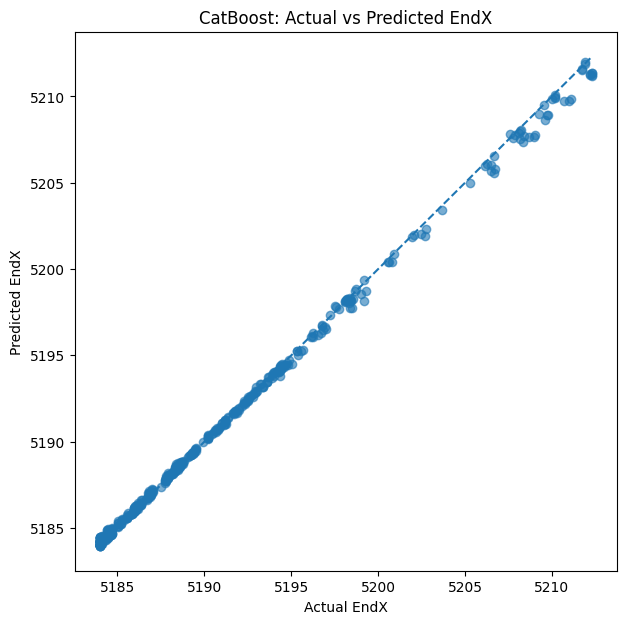

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual EndX")
plt.ylabel("Predicted EndX")
plt.title("CatBoost: Actual vs Predicted EndX")
plt.show()

In [35]:
y_EndY = merged_df["EndY"].copy()

y_train_EndY = y_EndY[train_mask]
y_test_EndY = y_EndY[test_mask]

print("Training samples:", len(y_train_EndY))
print("Testing samples:", len(y_test_EndY))

Training samples: 1768
Testing samples: 473


In [36]:
model_EndY = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

print("EndY model created.")

EndY model created.


In [37]:
model_EndY.fit(
    X_train,
    y_train_EndY,
    eval_set=(X_test, y_test_EndY),
    early_stopping_rounds=150
)

0:	learn: 4.3671952	test: 4.5182144	best: 4.5182144 (0)	total: 6.59ms	remaining: 9.88s
100:	learn: 0.6117227	test: 0.8026568	best: 0.8026568 (100)	total: 593ms	remaining: 8.21s
200:	learn: 0.2303918	test: 0.3522643	best: 0.3522643 (200)	total: 1.53s	remaining: 9.89s
300:	learn: 0.1538353	test: 0.2575816	best: 0.2575816 (300)	total: 2.44s	remaining: 9.72s
400:	learn: 0.1146287	test: 0.2223474	best: 0.2223474 (400)	total: 3.02s	remaining: 8.28s
500:	learn: 0.0906045	test: 0.2024545	best: 0.2024545 (500)	total: 3.74s	remaining: 7.46s
600:	learn: 0.0739533	test: 0.1896402	best: 0.1896402 (600)	total: 4.43s	remaining: 6.63s
700:	learn: 0.0634200	test: 0.1825978	best: 0.1825978 (700)	total: 5.16s	remaining: 5.88s
800:	learn: 0.0546293	test: 0.1772450	best: 0.1772426 (799)	total: 5.87s	remaining: 5.12s
900:	learn: 0.0475441	test: 0.1735719	best: 0.1735719 (900)	total: 6.63s	remaining: 4.41s
1000:	learn: 0.0420980	test: 0.1713780	best: 0.1713780 (1000)	total: 7.16s	remaining: 3.57s
1100:	learn

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [38]:
y_pred_EndY = model_EndY.predict(X_test)

mae_EndY = mean_absolute_error(y_test_EndY, y_pred_EndY)
rmse_EndY = mean_squared_error(y_test_EndY, y_pred_EndY) ** 0.5
r2_EndY = r2_score(y_test_EndY, y_pred_EndY)

print("MAE :", mae_EndY)
print("RMSE:", rmse_EndY)
print("R²  :", r2_EndY)

MAE : 0.10112966557524038
RMSE: 0.16275658160033474
R²  : 0.9987551436303448


In [39]:
y_EndZ = merged_df["EndZ"].copy()

y_train_EndZ = y_EndZ[train_mask]
y_test_EndZ = y_EndZ[test_mask]

print("Training samples:", len(y_train_EndZ))
print("Testing samples:", len(y_test_EndZ))

Training samples: 1768
Testing samples: 473


In [40]:
model_EndZ = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

print("EndZ model created.")

EndZ model created.


In [41]:
model_EndZ.fit(
    X_train,
    y_train_EndZ,
    eval_set=(X_test, y_test_EndZ),
    early_stopping_rounds=150
)

0:	learn: 1.9927513	test: 2.0635657	best: 2.0635657 (0)	total: 6.4ms	remaining: 9.59s
100:	learn: 0.3093152	test: 0.4072463	best: 0.4072463 (100)	total: 436ms	remaining: 6.03s
200:	learn: 0.1093744	test: 0.1898057	best: 0.1898057 (200)	total: 1.14s	remaining: 7.34s
300:	learn: 0.0696290	test: 0.1437939	best: 0.1437939 (300)	total: 1.84s	remaining: 7.34s
400:	learn: 0.0492093	test: 0.1230026	best: 0.1230026 (400)	total: 2.55s	remaining: 7s
500:	learn: 0.0383232	test: 0.1129719	best: 0.1129719 (500)	total: 3.29s	remaining: 6.56s
600:	learn: 0.0316069	test: 0.1073430	best: 0.1073430 (600)	total: 4.01s	remaining: 6.01s
700:	learn: 0.0264622	test: 0.1035583	best: 0.1035583 (700)	total: 4.69s	remaining: 5.34s
800:	learn: 0.0224756	test: 0.1010716	best: 0.1010716 (800)	total: 5.13s	remaining: 4.48s
900:	learn: 0.0195461	test: 0.0993808	best: 0.0993757 (899)	total: 5.56s	remaining: 3.69s
1000:	learn: 0.0170878	test: 0.0982518	best: 0.0982518 (1000)	total: 6s	remaining: 2.99s
1100:	learn: 0.014

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [42]:
y_pred_EndZ = model_EndZ.predict(X_test)

mae_EndZ = mean_absolute_error(y_test_EndZ, y_pred_EndZ)
rmse_EndZ = mean_squared_error(y_test_EndZ, y_pred_EndZ) ** 0.5
r2_EndZ = r2_score(y_test_EndZ, y_pred_EndZ)

print("MAE :", mae_EndZ)
print("RMSE:", rmse_EndZ)
print("R²  :", r2_EndZ)

MAE : 0.06882433824911849
RMSE: 0.09650916715118389
R²  : 0.9978924886175282


In [43]:
y_DirectionX = merged_df["DirectionX"].copy()

y_train_DirectionX = y_DirectionX[train_mask]
y_test_DirectionX = y_DirectionX[test_mask]

print("Training samples:", len(y_train_DirectionX))
print("Testing samples:", len(y_test_DirectionX))

Training samples: 1768
Testing samples: 473


In [44]:
model_DirectionX = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

print("DirectionX model created.")

DirectionX model created.


In [45]:
model_DirectionX.fit(
    X_train,
    y_train_DirectionX,
    eval_set=(X_test, y_test_DirectionX),
    early_stopping_rounds=150
)

0:	learn: 0.4165970	test: 0.4200895	best: 0.4200895 (0)	total: 6.58ms	remaining: 9.86s
100:	learn: 0.0378376	test: 0.0581944	best: 0.0581944 (100)	total: 455ms	remaining: 6.3s
200:	learn: 0.0079550	test: 0.0269002	best: 0.0269002 (200)	total: 1.41s	remaining: 9.12s
300:	learn: 0.0039185	test: 0.0228117	best: 0.0228117 (300)	total: 2.65s	remaining: 10.6s
400:	learn: 0.0024855	test: 0.0219100	best: 0.0219100 (400)	total: 3.33s	remaining: 9.11s
500:	learn: 0.0018354	test: 0.0216332	best: 0.0216318 (498)	total: 3.76s	remaining: 7.5s
600:	learn: 0.0014923	test: 0.0214624	best: 0.0214624 (600)	total: 4.19s	remaining: 6.26s
700:	learn: 0.0012701	test: 0.0213808	best: 0.0213808 (700)	total: 4.63s	remaining: 5.28s
800:	learn: 0.0010871	test: 0.0213356	best: 0.0213356 (800)	total: 5.05s	remaining: 4.41s
900:	learn: 0.0009538	test: 0.0213032	best: 0.0213018 (897)	total: 5.5s	remaining: 3.65s
1000:	learn: 0.0008477	test: 0.0212926	best: 0.0212920 (998)	total: 5.93s	remaining: 2.96s
1100:	learn: 0.

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [46]:
y_pred_DirectionX = model_DirectionX.predict(X_test)

mae_DirectionX = mean_absolute_error(
    y_test_DirectionX,
    y_pred_DirectionX
)

rmse_DirectionX = mean_squared_error(
    y_test_DirectionX,
    y_pred_DirectionX
) ** 0.5

r2_DirectionX = r2_score(
    y_test_DirectionX,
    y_pred_DirectionX
)

print("MAE :", mae_DirectionX)
print("RMSE:", rmse_DirectionX)
print("R²  :", r2_DirectionX)

MAE : 0.013078795384736065
RMSE: 0.021257379068895705
R²  : 0.9975550379130848


In [47]:
y_DirectionY = merged_df["DirectionY"].copy()

y_train_DirectionY = y_DirectionY[train_mask]
y_test_DirectionY = y_DirectionY[test_mask]

print("Training samples:", len(y_train_DirectionY))
print("Testing samples:", len(y_test_DirectionY))

Training samples: 1768
Testing samples: 473


In [48]:
model_DirectionY = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

print("DirectionY model created.")

DirectionY model created.


In [49]:
model_DirectionY.fit(
    X_train,
    y_train_DirectionY,
    eval_set=(X_test, y_test_DirectionY),
    early_stopping_rounds=150
)

0:	learn: 0.5757768	test: 0.5669843	best: 0.5669843 (0)	total: 24.6ms	remaining: 36.9s
100:	learn: 0.0485569	test: 0.0787852	best: 0.0787852 (100)	total: 967ms	remaining: 13.4s
200:	learn: 0.0111028	test: 0.0418661	best: 0.0418661 (200)	total: 2.23s	remaining: 14.4s
300:	learn: 0.0057780	test: 0.0370853	best: 0.0370853 (300)	total: 2.7s	remaining: 10.8s
400:	learn: 0.0039087	test: 0.0361683	best: 0.0361628 (399)	total: 3.15s	remaining: 8.64s
500:	learn: 0.0030145	test: 0.0359010	best: 0.0358995 (496)	total: 3.62s	remaining: 7.22s
600:	learn: 0.0024373	test: 0.0357083	best: 0.0357083 (600)	total: 4.07s	remaining: 6.08s
700:	learn: 0.0020568	test: 0.0355944	best: 0.0355930 (698)	total: 4.54s	remaining: 5.17s
800:	learn: 0.0017764	test: 0.0355298	best: 0.0355238 (784)	total: 4.99s	remaining: 4.35s
900:	learn: 0.0015645	test: 0.0354688	best: 0.0354688 (890)	total: 5.46s	remaining: 3.63s
1000:	learn: 0.0014106	test: 0.0354223	best: 0.0354219 (999)	total: 5.91s	remaining: 2.95s
1100:	learn: 

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [50]:
y_pred_DirectionY = model_DirectionY.predict(X_test)

mae_DirectionY = mean_absolute_error(y_test_DirectionY, y_pred_DirectionY)
rmse_DirectionY = mean_squared_error(y_test_DirectionY, y_pred_DirectionY) ** 0.5
r2_DirectionY = r2_score(y_test_DirectionY, y_pred_DirectionY)

print("DirectionY Results")
print("------------------")
print("MAE :", mae_DirectionY)
print("RMSE:", rmse_DirectionY)
print("R²  :", r2_DirectionY)

DirectionY Results
------------------
MAE : 0.02354537733096617
RMSE: 0.03532122031847575
R²  : 0.9963208234361088


In [51]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

remaining_targets = [
    "DirectionZ",
    "MidpointX",
    "MidpointY",
    "MidpointZ",
    "Length_ray"
]

models = {}
results = []

for target in remaining_targets:

    print("\n" + "=" * 50)
    print(f"Training model: {target}")
    print("=" * 50)

    y_target = merged_df[target]

    y_train_target = y_target[train_mask]
    y_test_target = y_target[test_mask]

    model = CatBoostRegressor(
        iterations=1500,
        depth=8,
        learning_rate=0.03,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        verbose=100
    )

    model.fit(
        X_train,
        y_train_target,
        eval_set=(X_test, y_test_target),
        early_stopping_rounds=150
    )

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test_target, y_pred)
    rmse = mean_squared_error(y_test_target, y_pred) ** 0.5
    r2 = r2_score(y_test_target, y_pred)

    models[target] = model

    results.append({
        "Target": target,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"\n{target} Results")
    print("------------------")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)

results_df = pd.DataFrame(results)

print("\n\nFINAL RESULTS")
print("==============================")
print(results_df)


Training model: DirectionZ
0:	learn: 0.5936805	test: 0.5996031	best: 0.5996031 (0)	total: 6.5ms	remaining: 9.74s
100:	learn: 0.0466800	test: 0.0818693	best: 0.0818693 (100)	total: 629ms	remaining: 8.71s
200:	learn: 0.0092368	test: 0.0448418	best: 0.0448418 (200)	total: 1.35s	remaining: 8.72s
300:	learn: 0.0046950	test: 0.0406240	best: 0.0406240 (300)	total: 2.07s	remaining: 8.25s
400:	learn: 0.0034414	test: 0.0397898	best: 0.0397897 (399)	total: 2.82s	remaining: 7.72s
500:	learn: 0.0027251	test: 0.0393886	best: 0.0393886 (500)	total: 3.5s	remaining: 6.97s
600:	learn: 0.0022297	test: 0.0391477	best: 0.0391477 (600)	total: 4.25s	remaining: 6.35s
700:	learn: 0.0019208	test: 0.0389977	best: 0.0389977 (700)	total: 4.79s	remaining: 5.46s
800:	learn: 0.0016810	test: 0.0389405	best: 0.0389382 (789)	total: 5.25s	remaining: 4.58s
900:	learn: 0.0015072	test: 0.0389313	best: 0.0389308 (898)	total: 5.69s	remaining: 3.78s
1000:	learn: 0.0013648	test: 0.0389116	best: 0.0389116 (1000)	total: 6.14s	re